<a href="https://colab.research.google.com/github/Harshith123456788/CS-AlliedBranches/blob/main/Loan_prediction_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement**

The goal of this project is to build a machine learning model to predict whether a loan will be paid back or not.
The dataset contains borrower information such as income, credit score, loan amount, and employment details.
Data preprocessing techniques are applied to handle missing values and convert categorical features into numerical form.
Different machine learning algorithms are trained and evaluated to find the model with the best prediction accuracy.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/loan_dataset_20000.csv")

In [3]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [4]:
df.shape

(20000, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [6]:
df.isnull().sum()

,0
age,0
gender,0
marital_status,0
education_level,0
annual_income,0
monthly_income,0
employment_status,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0


**Convert Categorical Columns**

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['gender', 'marital_status', 'education_level', 'employment_status','loan_purpose', 'grade_subgrade']

for col in cols:
  df[col] = le.fit_transform(df[col])

In [8]:
df.dtypes

,0
age,int64
gender,int64
marital_status,int64
education_level,int64
annual_income,float64
monthly_income,float64
employment_status,int64
debt_to_income_ratio,float64
credit_score,int64
loan_amount,float64


**Define Features (X) and Target (y)**

In [9]:
X = df.drop('loan_paid_back', axis=1)
Y = df['loan_paid_back']

**Train-Test Split**

Split the dataset into training and testing data

80% -training data

20% -testing data

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=2)

**Train First Model using Logistic Regression**

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Prediction**

In [12]:
y_pred = model.predict(X_test)

**Accuracy Score**

In [13]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(Y_test, y_pred))

Accuracy: 0.796


In [14]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_test, y_pred))

[[   3  814]
 [   2 3181]]


**Prediction for New Input**

In [15]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,1,1,2,24240.19,2020.02,0,0.074,743,17173.72,...,36,581.88,9,7,40833.47,24302.07,1,0,1,1
1,72,0,1,0,20172.98,1681.08,0,0.219,531,22663.89,...,60,573.17,25,5,27968.01,10803.01,1,0,3,1
2,49,0,2,1,26181.80,2181.82,0,0.234,779,3631.36,...,60,76.32,8,2,15502.25,4505.44,0,0,0,1
3,35,0,2,1,11873.84,989.49,0,0.264,809,14939.23,...,36,468.07,4,7,18157.79,5525.63,4,0,5,1
4,63,2,2,3,25326.44,2110.54,0,0.260,663,16551.71,...,60,395.50,19,1,17467.56,3593.91,2,0,2,1


In [16]:
import numpy as np

input_data = (59,1,1,2,24240.19,2020.02,0,0.074,743.0,17173.72,1,13.39,36.0,581.88,9,7,40833.47,24302.07,1,0,1)


input_array = np.asarray(input_data)
input_reshaped = input_array.reshape(1,-1)

prediction = model.predict(input_reshaped)

if prediction[0] == 1:
    print("Loan will be paid back")
else:
    print("Loan will NOT be paid back")

Loan will be paid back


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**KNN algo**

In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)


KNeighborsClassifier()

In [18]:
y_pred_knn = knn.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

print("KNN Accuracy:", accuracy_score(Y_test, y_pred_knn))

KNN Accuracy: 0.762


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[   3  814]
 [   2 3181]]


In [21]:
import numpy as np

input_data = (59,1,1,2,24240.19,2020.02,0,0.074,743.0,17173.72,1,13.39,36.0,581.88,9,7,40833.47,24302.07,1,0,1)


input_array = np.asarray(input_data)
input_reshaped = input_array.reshape(1,-1)

prediction = knn.predict(input_reshaped)

if prediction[0] == 1:
    print("Loan will be paid back")
else:
    print("Loan will NOT be paid back")

Loan will be paid back


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


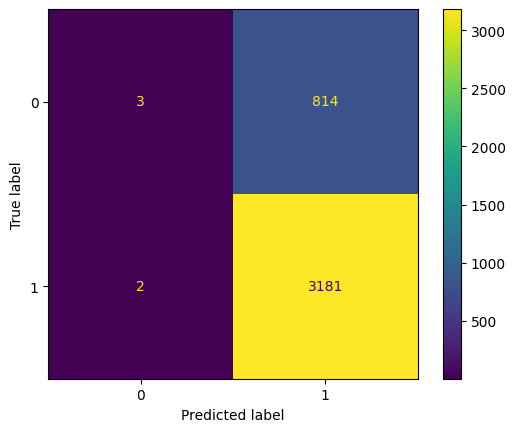

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred)

plt.show()

**Random Forest**

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=2)
rf.fit(X_train, Y_train)

RandomForestClassifier(random_state=2)

In [24]:
y_pred_rf = rf.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(Y_test, y_pred_rf))

Random Forest Accuracy: 0.9025


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred_rf)
print(cm)

[[ 451  366]
 [  24 3159]]


In [27]:
import numpy as np

input_data = (59,1,1,2,24240.19,2020.02,0,0.074,743.0,17173.72,1,13.39,36.0,581.88,9,7,40833.47,24302.07,1,0,1)  # example using first row

input_array = np.asarray(input_data)
input_reshaped = input_array.reshape(1,-1)

prediction = rf.predict(input_reshaped)

if prediction[0] == 1:
    print("Loan will be paid back")
else:
    print("Loan will NOT be paid back")

Loan will be paid back


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**Decision Tree**

In [28]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=2)
dt.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=2)

In [29]:
y_pred_dt = dt.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(Y_test, y_pred_dt))

Decision Tree Accuracy: 0.82825


In [31]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_test, y_pred_dt))

[[ 505  312]
 [ 375 2808]]


In [32]:
import numpy as np

input_data = X.iloc[0].values

input_array = np.asarray(input_data)
input_reshaped = input_array.reshape(1,-1)

prediction = dt.predict(input_reshaped)

if prediction[0] == 1:
    print("Loan will be paid back")
else:
    print("Loan will NOT be paid back")

Loan will be paid back


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**SVM(Support Vector Machine)**

In [33]:
from sklearn.svm import SVC
svm_model = SVC()
svm_model.fit(X_train, Y_train)

SVC()

In [34]:
y_pred_svm = svm_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(Y_test, y_pred_svm))

SVM Accuracy: 0.7955


In [36]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_test, y_pred_svm))

[[   0  817]
 [   1 3182]]


In [37]:
import numpy as np

input_data = X.iloc[0].values

input_array = np.asarray(input_data)
input_reshaped = input_array.reshape(1,-1)

prediction = svm_model.predict(input_reshaped)

if prediction[0] == 1:
    print("Loan will be paid back")
else:
    print("Loan will NOT be paid back")

Loan will be paid back


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


**Final Conclusion**

In this project, multiple machine learning algorithms were applied to predict whether a loan will be paid back or not. The models tested include Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM). After training and evaluating the models using accuracy score, Random Forest achieved the highest accuracy of 90% compared to the other algorithms. Therefore, Random Forest was selected as the best-performing model for this dataset to predict loan repayment.

In [40]:
import gradio as gr
import numpy as np

def predict_loan_rf(
    age, gender, marital_status, education_level, annual_income, monthly_income,
    employment_status, debt_to_income_ratio, credit_score, loan_amount,
    loan_purpose, interest_rate, loan_term, installment, grade_subgrade,
    num_of_open_accounts, total_credit_limit, current_balance,
    delinquency_history, public_records, num_of_delinquencies
):
    input_data = (
        age, gender, marital_status, education_level, annual_income, monthly_income,
        employment_status, debt_to_income_ratio, credit_score, loan_amount,
        loan_purpose, interest_rate, loan_term, installment, grade_subgrade,
        num_of_open_accounts, total_credit_limit, current_balance,
        delinquency_history, public_records, num_of_delinquencies
    )

    input_array = np.asarray(input_data, dtype=object) # Use dtype=object to handle mixed types if necessary, though numpy should handle conversion implicitly here
    input_reshaped = input_array.reshape(1, -1)

    prediction = rf.predict(input_reshaped)

    if prediction[0] == 1:
        return "Loan will be paid back"
    else:
        return "Loan will NOT be paid back"


In [41]:
import pandas as pd

# Get the first row of the feature set X as default values for the Gradio interface
default_values = X.iloc[0].tolist()

# Create Gradio input components for each feature
inputs = [
    gr.Number(label='Age', value=default_values[0]),
    gr.Number(label='Gender (0=Female, 1=Male, 2=Other)', value=default_values[1]),
    gr.Number(label='Marital Status (0=Divorced, 1=Married, 2=Single)', value=default_values[2]),
    gr.Number(label='Education Level (0=Bachelors, 1=High School, 2=Masters, 3=Other, 4=PhD)', value=default_values[3]),
    gr.Number(label='Annual Income', value=default_values[4]),
    gr.Number(label='Monthly Income', value=default_values[5]),
    gr.Number(label='Employment Status (0=Employed, 1=Unemployed, 2=Self-Employed)', value=default_values[6]),
    gr.Number(label='Debt to Income Ratio', value=default_values[7]),
    gr.Number(label='Credit Score', value=default_values[8]),
    gr.Number(label='Loan Amount', value=default_values[9]),
    gr.Number(label='Loan Purpose (0=Business, 1=Car, 2=Credit Card, 3=Debt Consolidation, 4=Education, 5=Home Improvement, 6=Medical, 7=Other, 8=Wedding)', value=default_values[10]),
    gr.Number(label='Interest Rate', value=default_values[11]),
    gr.Number(label='Loan Term', value=default_values[12]),
    gr.Number(label='Installment', value=default_values[13]),
    gr.Number(label='Grade Subgrade (0-34, encoded values)', value=default_values[14]), # This needs to be mapped to actual grades for a user-friendly UI
    gr.Number(label='Number of Open Accounts', value=default_values[15]),
    gr.Number(label='Total Credit Limit', value=default_values[16]),
    gr.Number(label='Current Balance', value=default_values[17]),
    gr.Number(label='Delinquency History', value=default_values[18]),
    gr.Number(label='Public Records', value=default_values[19]),
    gr.Number(label='Number of Delinquencies', value=default_values[20])
]

# Launch the Gradio interface
iface = gr.Interface(
    fn=predict_loan_rf,
    inputs=inputs,
    outputs="text",
    title="Loan Repayment Prediction (Random Forest Model)",
    description="Enter the borrower's details to predict if the loan will be paid back."
)

iface.launch(debug=True, share=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b2a0bd0f6e750206d2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Using existing dataset file at: .gradio/flagged/dataset1.csv
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b2a0bd0f6e750206d2.gradio.live
